# 09 — Token Interpretability


In [1]:
import os, math, json, shutil, time, pickle
from dataclasses import dataclass, field
from collections import defaultdict
from typing import List, Dict, Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
torch.manual_seed(42); np.random.seed(42)

# === Publication-grade matplotlib style ===
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.4,
    "lines.markersize": 5,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Consistent palette across all 5 notebooks.
COLORS = {
    "softmax":  "#C0392B",   # red
    "sigmoid":  "#27AE60",   # green
    "neutral":  "#2C3E50",   # near-black
    "grey":     "#7F8C8D",
    "lightgrey":"#BDC3C7",
    "yellow":   "#F39C12",
    "blue":     "#2980B9",
    "purple":   "#8E44AD",
}

def style_for(spec):
    """Return (color, linestyle, marker, label) for a model spec tuple
    (name, display, use_rope, use_sigmoid, gated)."""
    _, display, use_rope, use_sigmoid, _ = spec
    color = COLORS["sigmoid"] if use_sigmoid else COLORS["softmax"]
    ls    = "-" if use_rope else "--"
    mk    = "o" if use_rope else "s"
    return color, ls, mk, display


Mounted at /content/drive
Device: cuda


In [2]:
@dataclass
class Config:
    d_model: int = 768
    n_layer: int = 12
    n_head: int = 12
    d_ff: int = 3072
    block_size: int = 512
    vocab_size: int = 50257
    rope_base: float = 10000.0
    use_rope: bool = True       # toggled per spec
    use_sigmoid: bool = False   # toggled per spec

cfg_base = Config()

BASE       = "/content/drive/MyDrive/SigEvict"
DATA_DIR   = f"{BASE}/data"
MODEL_DIR  = f"{BASE}/models"
RESULT_DIR = f"{BASE}/results"
FIG_DIR    = f"{BASE}/figures"
TBL_DIR    = f"{BASE}/tables"
for d in [RESULT_DIR, FIG_DIR, TBL_DIR]: os.makedirs(d, exist_ok=True)

# 2 x 2 x 2 factorial: (attention) x (gate) x (position)
MODEL_SPECS = [
    # name                                  display          use_rope use_sigmoid gated
    ("gpt2_12L_dense_softmax",              "SM RoPE",         True,    False,   False),
    ("gpt2_12L_softmax_gated",              "SM+G RoPE",       True,    False,   True ),
    ("gpt2_12L_sigmoid_no_gate",            "Sig RoPE",        True,    True,    False),
    ("gpt2_12L_sigmoid_gated",              "Sig+G RoPE",      True,    True,    True ),
    ("gpt2_12L_dense_softmax_norope",       "SM NoPE",         False,   False,   False),
    ("gpt2_12L_softmax_gated_norope",       "SM+G NoPE",       False,   False,   True ),
    ("gpt2_12L_sigmoid_no_gate_norope",     "Sig NoPE",        False,   True,    False),
    ("gpt2_12L_sigmoid_gated_norope",       "Sig+G NoPE",      False,   True,    True ),
]
GATED_SPECS = [s for s in MODEL_SPECS if s[4]]
DENSE_SPECS = [s for s in MODEL_SPECS if not s[4]]
print(f"Registered {len(MODEL_SPECS)} models ({len(GATED_SPECS)} gated, {len(DENSE_SPECS)} dense)")

# Smoke toggle
SMOKE = False


Registered 8 models (4 gated, 4 dense)


## Model definitions (unified across all 8 specs)


In [3]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_len=2048, base=10000.0):
        super().__init__()
        self.register_buffer("inv_freq", 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim)))
    def forward(self, seq_len, device):
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        return emb.cos(), emb.sin()

def apply_rope(x, cos, sin, offset=0):
    d = x.shape[-1] // 2
    T = x.shape[2]
    x1, x2 = x[..., :d], x[..., d:]
    c = cos[offset:offset+T].unsqueeze(0).unsqueeze(0)
    s = sin[offset:offset+T].unsqueeze(0).unsqueeze(0)
    return torch.cat([x1*c[...,:d] - x2*s[...,:d], x1*s[...,:d] + x2*c[...,:d]], dim=-1)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.d_model, cfg.d_ff, bias=False)
        self.proj = nn.Linear(cfg.d_ff, cfg.d_model, bias=False)
    def forward(self, x): return self.proj(F.gelu(self.fc(x)))


In [4]:
class SoftmaxAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        if cfg.use_rope:
            self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.masked_fill(self.mask[:T, :T], float("-inf"))
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            att = att + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        att = F.softmax(att, dim=-1)
        return self.c_proj((att @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(start_pos + T, x.device)
            q = apply_rope(q, cos, sin, offset=start_pos)
            k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        att = (q @ k.transpose(-2, -1)) * self.scale
        causal = self.mask[start_pos:start_pos+T, :T_full]
        att = att.masked_fill(causal.unsqueeze(0).unsqueeze(0), float("-inf"))
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            att = att + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        att = F.softmax(att, dim=-1)
        y = (att @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)


class SigmoidAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        if cfg.use_rope:
            self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())
        self.register_buffer("pos_bias", -torch.log(torch.arange(cfg.block_size, dtype=torch.float32) + 1))

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        logits = (q @ k.transpose(-2, -1)) * self.scale + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        attn = torch.sigmoid(logits.masked_fill(self.mask[:T, :T], -1e9)).masked_fill(self.mask[:T, :T], 0.0)
        return self.c_proj((attn @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(start_pos + T, x.device)
            q = apply_rope(q, cos, sin, offset=start_pos)
            k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        logits = (q @ k.transpose(-2, -1)) * self.scale
        if T == 1:
            logits = logits + (-math.log(start_pos + 1))
        else:
            logits = logits + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        causal = self.mask[start_pos:start_pos+T, :T_full]
        attn = torch.sigmoid(logits.masked_fill(causal.unsqueeze(0).unsqueeze(0), -1e9))
        attn = attn.masked_fill(causal.unsqueeze(0).unsqueeze(0), 0.0)
        y = (attn @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)


In [5]:
class Block(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), attn_cls(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))
    def forward_kv(self, x, kv_cache=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x, new_kv

class GatedBlock(nn.Module):
    def __init__(self, cfg, layer_idx, attn_cls):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), attn_cls(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
        self.has_gate = layer_idx < cfg.n_layer - 1
        if self.has_gate:
            self.gate = nn.Linear(cfg.d_model, 1, bias=True)
    def forward(self, x, kv_mask=None):
        x = x + self.attn(self.ln1(x), kv_mask=kv_mask)
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, g
    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache,
                                                kv_mask=kv_mask, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, new_kv, g


class GPT2Dense(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([Block(cfg, attn_cls) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        for b in self.blocks: x = b(x)
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss

    def prefill(self, idx):
        B, T = idx.shape
        x = self.wte(idx)
        caches = []
        for block in self.blocks:
            x, kv = block.forward_kv(x, kv_cache=None, start_pos=0)
            caches.append(kv)
        logits = self.head(self.ln_f(x))
        return logits, caches

    def decode_step(self, tok, pos, caches):
        x = self.wte(tok)
        new_caches = []
        for l, block in enumerate(self.blocks):
            x, kv = block.forward_kv(x, kv_cache=caches[l], start_pos=pos)
            new_caches.append(kv)
        return self.head(self.ln_f(x)).squeeze(1), new_caches


class GPT2Gated(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([GatedBlock(cfg, i, attn_cls) for i in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        kv_mask, gates = None, []
        for b in self.blocks:
            x, g = b(x, kv_mask=kv_mask)
            if g is not None: gates.append(g)
            kv_mask = g
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        budget = sum(g.mean() for g in gates) / len(gates) if gates else None
        return logits, loss, budget, gates

    def prefill(self, idx):
        B, T = idx.shape
        x = self.wte(idx)
        caches, cache_masks = [], []
        prev_mask = torch.ones(B, T, 1, device=idx.device)
        for block in self.blocks:
            x, kv, gate = block.forward_kv(x, kv_cache=None, kv_mask=prev_mask, start_pos=0)
            caches.append(kv); cache_masks.append(prev_mask)
            prev_mask = gate if gate is not None else torch.ones(B, T, 1, device=idx.device)
        return self.head(self.ln_f(x)), caches, cache_masks

    def decode_step(self, tok, pos, caches, cache_masks):
        B = tok.size(0)
        x = self.wte(tok)
        new_caches, new_cache_masks = [], []
        prev_gate_new = torch.ones(B, 1, 1, device=tok.device)
        for l, block in enumerate(self.blocks):
            kv_mask = torch.cat([cache_masks[l], prev_gate_new], dim=1)
            x, kv, gate = block.forward_kv(x, kv_cache=caches[l], kv_mask=kv_mask, start_pos=pos)
            new_caches.append(kv); new_cache_masks.append(kv_mask)
            prev_gate_new = gate if gate is not None else torch.ones(B, 1, 1, device=tok.device)
        return self.head(self.ln_f(x)).squeeze(1), new_caches, new_cache_masks


def build_model(spec):
    name, display, use_rope, use_sigmoid, gated = spec
    cfg = Config()
    cfg.use_rope = use_rope
    cfg.use_sigmoid = use_sigmoid
    attn_cls = SigmoidAttention if use_sigmoid else SoftmaxAttention
    model = GPT2Gated(cfg, attn_cls) if gated else GPT2Dense(cfg, attn_cls)
    return model, cfg

def load_model(spec, device=device):
    name = spec[0]
    ckpt = torch.load(f"{MODEL_DIR}/{name}.pt", map_location=device, weights_only=False)
    model, cfg = build_model(spec)
    missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
    if missing or unexpected:
        print(f"  [warn] {name}: missing={len(missing)}, unexpected={len(unexpected)}")
    model = model.to(device).eval()
    best_tau = ckpt.get("best_tau", None)
    return model, cfg, best_tau


In [6]:
@torch.no_grad()
def extract_attn_and_gate(model, cfg, input_ids):
    """Walk the model block-by-block, returning per-layer head-averaged attention
    and per-layer per-position gate (only for gated models)."""
    B, T = input_ids.shape
    x = model.wte(input_ids)
    C = x.shape[-1]
    attn_maps, gate_vals = [], []
    kv_mask = None

    for block in model.blocks:
        attn_mod = block.attn
        h = block.ln1(x)
        q, k, v = attn_mod.c_attn(h).split(C, dim=-1)
        q = q.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        k = k.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        v = v.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        q, k = attn_mod.q_norm(q), attn_mod.k_norm(k)
        if cfg.use_rope:
            cos, sin = attn_mod.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)

        is_sigmoid = hasattr(attn_mod, "pos_bias")
        if is_sigmoid:
            logits = (q @ k.transpose(-2, -1)) * attn_mod.scale
            logits = logits + attn_mod.pos_bias[:T].view(1, 1, T, 1)
            if kv_mask is not None:
                logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            logits = logits.masked_fill(attn_mod.mask[:T, :T], -1e9)
            weights = torch.sigmoid(logits).masked_fill(attn_mod.mask[:T, :T], 0.0)
        else:
            logits = (q @ k.transpose(-2, -1)) * attn_mod.scale
            logits = logits.masked_fill(attn_mod.mask[:T, :T], float("-inf"))
            if kv_mask is not None:
                logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            weights = F.softmax(logits, dim=-1)

        attn_maps.append(weights.float().cpu())

        if hasattr(block, "has_gate"):
            x, g = block(x, kv_mask=kv_mask)
            if g is not None:
                gate_vals.append(g.squeeze(-1).float().cpu())
            kv_mask = g
        else:
            x = block(x)

    return attn_maps, gate_vals


## Load test tokens + tokenizer


In [7]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
V = cfg_base.vocab_size

LOCAL = "/content/local_data"; os.makedirs(LOCAL, exist_ok=True)
src, dst = f"{DATA_DIR}/owt_test_1M.pt", f"{LOCAL}/owt_test_1M.pt"
if not os.path.exists(dst):
    print("Copying test tokens to local SSD...")
    shutil.copy(src, dst)
test_tokens = torch.load(dst, weights_only=True)
print(f"Test tokens: {len(test_tokens):,}")

# Load best_tau per gated model so we can compute actual_drop_rate = P(gate < best_tau)
try:
    with open(f"{RESULT_DIR}/best_taus.json") as f:
        best_taus = json.load(f)["best_taus"]
    print(f"Loaded best_taus: {best_taus}")
except FileNotFoundError:
    print("[warn] best_taus.json not found - run 06 first; falling back to tau=0.5 for actual_drop_rate")
    best_taus = {s[0]: 0.5 for s in MODEL_SPECS if s[4]}

T_PER_SEQ = 512
N_TEST = 20 if SMOKE else (len(test_tokens) - 1) // T_PER_SEQ
print(f"N_TEST = {N_TEST}  ({N_TEST * T_PER_SEQ:,} tokens for token-level stats)")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Copying test tokens to local SSD...
Test tokens: 1,000,000
Loaded best_taus: {'gpt2_12L_softmax_gated': 0.01, 'gpt2_12L_sigmoid_gated': 0.05, 'gpt2_12L_softmax_gated_norope': 0.01, 'gpt2_12L_sigmoid_gated_norope': 0.05}
N_TEST = 1953  (999,936 tokens for token-level stats)


## Collect per-(token_id, layer) gate sums on the test set


In [8]:
@torch.no_grad()
def collect_token_gate_stats(model, cfg, tokens, n_seqs, T, V, tau=None):
    """For each token id, accumulate per-layer gate values:
       gate_sum[v, l]   = sum of soft gate values for token id v at layer l
       gate_sqsum[v, l] = sum of squared soft gate values
       gate_count[v, l] = number of occurrences
       drop_count[v, l] = number of occurrences where g < tau (actual eviction count)
       Also gate-vs-absolute-position stats."""
    L = cfg.n_layer - 1
    gate_sum   = torch.zeros(V, L)
    gate_sqsum = torch.zeros(V, L)
    gate_count = torch.zeros(V, L, dtype=torch.long)
    drop_count = torch.zeros(V, L, dtype=torch.long)
    pos_sum    = torch.zeros(T, L)
    pos_count  = torch.zeros(T, L, dtype=torch.long)

    for si in range(n_seqs):
        s = si * T
        if s + T > len(tokens): break
        ids = tokens[s:s+T]
        toks_in = ids.unsqueeze(0).to(device)
        _, gates = extract_attn_and_gate(model, cfg, toks_in)
        ids_cpu = ids.long()
        for li, g in enumerate(gates):
            gv = g[0].cpu().float()
            gate_sum[:, li].scatter_add_(0, ids_cpu, gv)
            gate_sqsum[:, li].scatter_add_(0, ids_cpu, gv * gv)
            gate_count[:, li].scatter_add_(0, ids_cpu, torch.ones_like(gv, dtype=torch.long))
            if tau is not None:
                dropped = (gv < tau).long()
                drop_count[:, li].scatter_add_(0, ids_cpu, dropped)
            pos_sum[:, li]   += gv
            pos_count[:, li] += 1
    return gate_sum, gate_sqsum, gate_count, drop_count, pos_sum, pos_count

token_stats = {}
for spec in [s for s in MODEL_SPECS if s[4]]:
    name, display = spec[0], spec[1]
    tau = best_taus.get(name)
    print(f">>> {display}  (using best_τ={tau} for actual-drop-rate)")
    model, cfg, _ = load_model(spec)
    gs, gsq, gc, dc, ps, pc = collect_token_gate_stats(
        model, cfg, test_tokens, N_TEST, T_PER_SEQ, V, tau=tau)
    token_stats[name] = {"gate_sum": gs, "gate_sqsum": gsq, "gate_count": gc,
                         "drop_count": dc, "pos_sum": ps, "pos_count": pc,
                         "spec": spec, "best_tau": tau}
    print(f"   total gate observations = {int(gc.sum()):,}  unique tokens seen = "
          f"{int((gc.sum(-1) > 0).sum()):,}")
    del model; torch.cuda.empty_cache()


>>> SM+G RoPE  (using best_τ=0.01 for actual-drop-rate)
   total gate observations = 10,999,296  unique tokens seen = 37,302
>>> Sig+G RoPE  (using best_τ=0.05 for actual-drop-rate)
   total gate observations = 10,999,296  unique tokens seen = 37,302
>>> SM+G NoPE  (using best_τ=0.01 for actual-drop-rate)
   total gate observations = 10,999,296  unique tokens seen = 37,302
>>> Sig+G NoPE  (using best_τ=0.05 for actual-drop-rate)
   total gate observations = 10,999,296  unique tokens seen = 37,302


## Top-10 dropped / top-10 reserved tokens by mean learned gate value


In [9]:
def top_k_table(stats, tokenizer, k=10, min_count=100, layer=None):
    gs, gc = stats["gate_sum"], stats["gate_count"]
    if layer is None:
        agg_sum = gs.sum(-1)
        agg_cnt = gc.sum(-1)
    else:
        agg_sum = gs[:, layer]
        agg_cnt = gc[:, layer]
    valid = agg_cnt >= min_count
    if valid.sum() == 0:
        print("  no tokens passed min_count; lower min_count"); return [], []
    means = torch.where(valid, agg_sum / agg_cnt.clamp(min=1).float(), torch.tensor(float("nan")))
    valid_ids = valid.nonzero(as_tuple=True)[0]
    valid_means = means[valid_ids]

    drop_order = valid_means.argsort()[:k]
    keep_order = valid_means.argsort(descending=True)[:k]
    drops = [(int(valid_ids[i]), float(valid_means[i]), int(agg_cnt[valid_ids[i]])) for i in drop_order]
    keeps = [(int(valid_ids[i]), float(valid_means[i]), int(agg_cnt[valid_ids[i]])) for i in keep_order]
    return drops, keeps

def fmt_token(tid, tokenizer):
    s = tokenizer.decode([tid])
    return repr(s)[:18]

# Layer-averaged top-10 per gated model
top10_results = {}
print("\n" + "=" * 80)
print("TOP-10 DROPPED / RESERVED TOKENS  (layer-averaged, min_count=100)")
print("=" * 80)
for name, st in token_stats.items():
    spec = st["spec"]
    drops, keeps = top_k_table(st, tokenizer, k=10, min_count=100)
    top10_results[name] = {"drops": drops, "keeps": keeps}
    print(f"\n--- {spec[1]} ---")
    print(f"  {'rank':>4} | {'most dropped':<35} | {'most reserved':<35}")
    print(f"  {'-'*4} | {'-'*35} | {'-'*35}")
    for r in range(10):
        d_id, d_g, d_n = drops[r]
        k_id, k_g, k_n = keeps[r]
        d_str = f"{d_g:.3f} (n={d_n}) {fmt_token(d_id, tokenizer)}"
        k_str = f"{k_g:.3f} (n={k_n}) {fmt_token(k_id, tokenizer)}"
        print(f"  {r+1:>4} | {d_str:<35} | {k_str:<35}")

# Per-layer top-10 (L0, L_mid, L_last_gated)
PER_LAYER_TOP = {}
for name, st in token_stats.items():
    spec = st["spec"]; n_gate = st["gate_sum"].shape[1]
    PER_LAYER_TOP[name] = {}
    for li in [0, n_gate//2, n_gate-1]:
        PER_LAYER_TOP[name][li] = top_k_table(st, tokenizer, k=10, min_count=50, layer=li)

print("\n" + "=" * 80)
print("PER-LAYER TOP-10 (L0, L_mid, L_last_gated; min_count=50)")
print("=" * 80)
for name, by_layer in PER_LAYER_TOP.items():
    spec_name = next(s[1] for s in MODEL_SPECS if s[0]==name)
    print(f"\n=== {spec_name} ===")
    for li, (drops, keeps) in by_layer.items():
        print(f"\n  Layer {li}:")
        for r in range(min(10, len(drops))):
            d_id, d_g, d_n = drops[r]; k_id, k_g, k_n = keeps[r]
            print(f"    {r+1:>2}. drop {d_g:.3f} {fmt_token(d_id, tokenizer):<14}  "
                  f"keep {k_g:.3f} {fmt_token(k_id, tokenizer):<14}")



TOP-10 DROPPED / RESERVED TOKENS  (layer-averaged, min_count=100)

--- SM+G RoPE ---
  rank | most dropped                        | most reserved                      
  ---- | ----------------------------------- | -----------------------------------
     1 | 0.066 (n=124806) '�'                | 0.506 (n=154) ' ("'                
     2 | 0.067 (n=84216) '�'                 | 0.473 (n=4763) '�'                 
     3 | 0.086 (n=409937) ' the'             | 0.457 (n=154) ' \xad'              
     4 | 0.092 (n=23760) 'The'               | 0.455 (n=3982) " '"                
     5 | 0.103 (n=175714) ' a'               | 0.443 (n=176) 'Merit'              
     6 | 0.105 (n=30481) ' The'              | 0.442 (n=33187) '�'                
     7 | 0.109 (n=26565) ' an'               | 0.437 (n=22726) ' "'               
     8 | 0.109 (n=2123) ' edit'              | 0.426 (n=176) ' caption'           
     9 | 0.114 (n=5753) 'It'                 | 0.405 (n=187) '�'                  
 

## Top-10 by **actual eviction frequency** under hard τ-thresholding


In [10]:
def top_k_actual_drop(stats, tokenizer, k=10, min_count=100, layer=None):
    gc = stats["gate_count"]; dc = stats["drop_count"]
    if layer is None:
        agg_drop  = dc.sum(-1).float()
        agg_total = gc.sum(-1).float()
    else:
        agg_drop  = dc[:, layer].float()
        agg_total = gc[:, layer].float()
    valid = agg_total >= min_count
    if valid.sum() == 0: return [], []
    rates = torch.where(valid, agg_drop / agg_total.clamp(min=1), torch.tensor(float("nan")))
    valid_ids = valid.nonzero(as_tuple=True)[0]
    valid_rates = rates[valid_ids]
    drop_order = valid_rates.argsort(descending=True)[:k]   # highest drop rate first
    keep_order = valid_rates.argsort()[:k]                  # lowest drop rate first (most retained)
    drops = [(int(valid_ids[i]), float(valid_rates[i]), int(agg_total[valid_ids[i]])) for i in drop_order]
    keeps = [(int(valid_ids[i]), float(valid_rates[i]), int(agg_total[valid_ids[i]])) for i in keep_order]
    return drops, keeps

actual_top10 = {}
print("\n" + "=" * 90)
print("TOP-10 BY ACTUAL DROP RATE  P(g < best_τ)  (layer-averaged, min_count=100)")
print("=" * 90)
for name, st in token_stats.items():
    spec = st["spec"]; tau = st["best_tau"]
    drops, keeps = top_k_actual_drop(st, tokenizer, k=10, min_count=100)
    actual_top10[name] = {"drops": drops, "keeps": keeps, "tau": tau}
    print(f"\n--- {spec[1]}  (τ = {tau:.3f}) ---")
    print(f"  {'rank':>4} | {'most-evicted (high drop_rate)':<40} | {'most-retained (low drop_rate)':<40}")
    print(f"  {'-'*4} | {'-'*40} | {'-'*40}")
    for r in range(10):
        d_id, d_r, d_n = drops[r]
        k_id, k_r, k_n = keeps[r]
        print(f"  {r+1:>4} | rate={d_r*100:5.1f}% n={d_n:>5} {fmt_token(d_id, tokenizer):<14} | "
              f"rate={k_r*100:5.1f}% n={k_n:>5} {fmt_token(k_id, tokenizer):<14}")



TOP-10 BY ACTUAL DROP RATE  P(g < best_τ)  (layer-averaged, min_count=100)

--- SM+G RoPE  (τ = 0.010) ---
  rank | most-evicted (high drop_rate)            | most-retained (low drop_rate)           
  ---- | ---------------------------------------- | ----------------------------------------
     1 | rate= 36.4% n=  121 'acial'        | rate=  0.0% n=  176 'Merit'       
     2 | rate= 36.4% n=  143 ' roof'        | rate=  0.0% n=  143 'ADVERTISEMENT'
     3 | rate= 36.4% n=  121 ' kitchen'     | rate=  0.0% n=  539 ' (@'         
     4 | rate= 36.4% n=  165 ' sperm'       | rate=  0.0% n=  429 '."['         
     5 | rate= 36.4% n=  121 ' monastery'   | rate=  0.0% n=  198 'UTC'         
     6 | rate= 36.4% n=  110 ' forensic'    | rate=  0.0% n=  451 'Advertisement'
     7 | rate= 36.4% n=  121 ' temple'      | rate=  0.0% n=  165 ' ~'          
     8 | rate= 36.4% n=  132 ' cannabis'    | rate=  0.0% n=  198 ' Joined'     
     9 | rate= 36.4% n=  198 ' vitamin'     | rate=  0.0

## Fig 4 — top-10 drop/reserve bar chart (4 gated models, paper-ready)


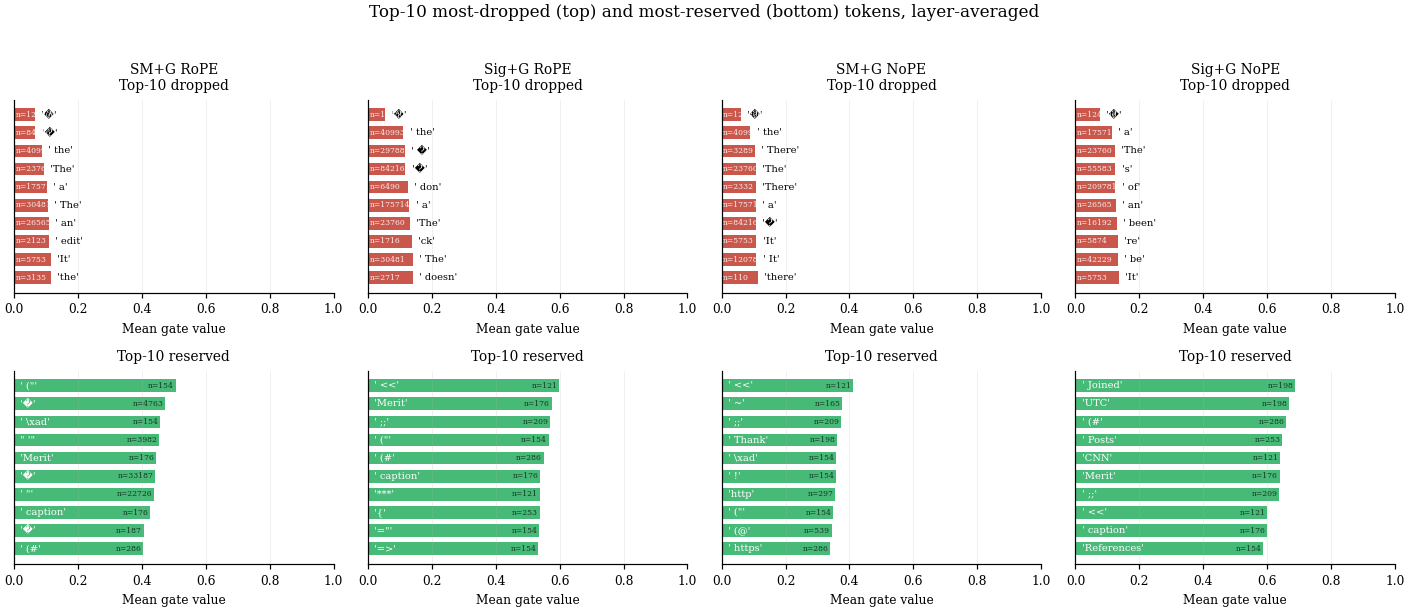

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5), sharex=False, sharey=False)
GATED = [s for s in MODEL_SPECS if s[4]]

for col, spec in enumerate(GATED):
    name = spec[0]
    if name not in top10_results: continue
    drops = top10_results[name]["drops"]
    keeps = top10_results[name]["keeps"]

    # Top: most dropped (red bars, low gate)
    ax = axes[0, col]
    ranks = list(range(10))
    means = [d[1] for d in drops]
    labels = [fmt_token(d[0], tokenizer) for d in drops]
    bars = ax.barh(ranks[::-1], means, color=COLORS["softmax"], alpha=0.85, height=0.7)
    for r, (m, lbl, d) in enumerate(zip(means, labels, drops)):
        ax.text(m + 0.02, 9-r, f"{lbl}", fontsize=6.5, va="center", ha="left")
        ax.text(0.005, 9-r, f"n={d[2]}", fontsize=5, va="center", ha="left",
                color="white", alpha=0.9)
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Mean gate value", fontsize=8)
    ax.set_title(f"{spec[1]}\nTop-10 dropped", fontsize=9)
    ax.grid(axis="x", alpha=0.3, lw=0.4)

    # Bottom: most reserved (green bars, high gate)
    ax = axes[1, col]
    means = [k[1] for k in keeps]
    labels = [fmt_token(k[0], tokenizer) for k in keeps]
    bars = ax.barh(ranks[::-1], means, color=COLORS["sigmoid"], alpha=0.85, height=0.7)
    for r, (m, lbl, k) in enumerate(zip(means, labels, keeps)):
        # Place label inside the bar (since bar fills most of axis)
        ax.text(0.02, 9-r, f"{lbl}", fontsize=6.5, va="center", ha="left", color="white")
        ax.text(m - 0.005, 9-r, f"n={k[2]}", fontsize=5, va="center", ha="right",
                color="black", alpha=0.7)
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Mean gate value", fontsize=8)
    ax.set_title("Top-10 reserved", fontsize=9)
    ax.grid(axis="x", alpha=0.3, lw=0.4)

plt.suptitle("Top-10 most-dropped (top) and most-reserved (bottom) tokens, layer-averaged",
             fontsize=11, y=1.02)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/fig4_token_top10.{ext}", dpi=300)
plt.show()


## Token-type bucket analysis (content vs stopword vs punct vs newline vs digit)


In [12]:
import string
STOPWORDS = {"the", "a", "an", "and", "or", "but", "of", "in", "on", "to", "for",
             "is", "was", "are", "were", "be", "been", "being", "have", "has", "had",
             "it", "he", "she", "i", "you", "we", "they", "that", "this", "these", "those",
             "with", "by", "from", "as", "at", "if", "not", "no"}
PUNCT = set(string.punctuation)

def bucket_of(s):
    raw = s
    s = s.strip()
    if "\n" in raw or "\t" in raw:
        return "newline"
    if len(s) == 0:
        return "whitespace"
    if all(c in PUNCT for c in s):
        return "punctuation"
    if s.isdigit():
        return "digit"
    if s.lower() in STOPWORDS:
        return "stopword"
    return "content"

def bucket_means(stats, tokenizer, min_count=10):
    """Per-bucket mean gate (layer-avg)."""
    gs, gc = stats["gate_sum"], stats["gate_count"]
    out = defaultdict(lambda: {"sum": 0.0, "cnt": 0, "n_tokens": 0})
    for tid in range(gs.shape[0]):
        c = int(gc[tid].sum())
        if c < min_count: continue
        s = float(gs[tid].sum())
        b = bucket_of(tokenizer.decode([tid]))
        out[b]["sum"] += s
        out[b]["cnt"] += c
        out[b]["n_tokens"] += 1
    return {b: {"mean": d["sum"]/d["cnt"], "cnt": d["cnt"], "n_tokens": d["n_tokens"]}
            for b, d in out.items() if d["cnt"] > 0}

bucket_results = {name: bucket_means(st, tokenizer) for name, st in token_stats.items()}
buckets_order = ["content", "stopword", "punctuation", "newline", "whitespace", "digit"]

# Print + save table
lines = ["% Token-type bucket gate analysis",
         "\\begin{tabular}{l" + "c"*len(buckets_order) + "}",
         "\\toprule",
         "Model & " + " & ".join(buckets_order) + " \\\\",
         "\\midrule"]
print("\n" + "=" * 90)
print("TOKEN-BUCKET MEAN GATE")
print("=" * 90)
print(f"{'Model':<14} | " + " | ".join(f"{b[:10]:>10}" for b in buckets_order))
for name, br in bucket_results.items():
    spec_name = next(s[1] for s in MODEL_SPECS if s[0]==name)
    cells_str = []
    for b in buckets_order:
        if b in br:
            cells_str.append(f"{br[b]['mean']:>10.3f}")
        else:
            cells_str.append(f"{'--':>10}")
    print(f"{spec_name:<14} | " + " | ".join(cells_str))
    cells_tex = " & ".join(f"{br[b]['mean']:.3f}" if b in br else "--" for b in buckets_order)
    lines.append(f"{spec_name} & {cells_tex} \\\\")
lines += ["\\bottomrule", "\\end{tabular}"]
with open(f"{TBL_DIR}/table_token_buckets.tex", "w") as f: f.write("\n".join(lines))
print(f"\nSaved {TBL_DIR}/table_token_buckets.tex")



TOKEN-BUCKET MEAN GATE
Model          |    content |   stopword | punctuatio |    newline | whitespace |      digit
SM+G RoPE      |      0.213 |      0.144 |      0.224 |      0.170 |      0.274 |      0.196
Sig+G RoPE     |      0.272 |      0.184 |      0.270 |      0.176 |      0.328 |      0.235
SM+G NoPE      |      0.223 |      0.144 |      0.195 |      0.135 |      0.334 |      0.224
Sig+G NoPE     |      0.281 |      0.178 |      0.254 |      0.273 |      0.455 |      0.263

Saved /content/drive/MyDrive/SigEvict/tables/table_token_buckets.tex


## Sup. Fig — gate vs absolute position (gate sink phenomenon)


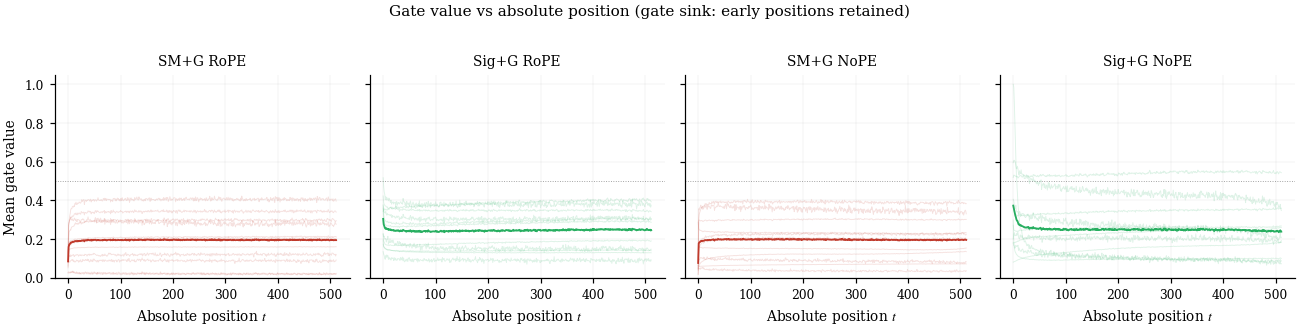

In [13]:
fig, axes = plt.subplots(1, len(GATED), figsize=(3.0*len(GATED), 3.0), sharey=True)
for ax, spec in zip(axes if len(GATED)>1 else [axes], GATED):
    name = spec[0]
    if name not in token_stats: continue
    ps, pc = token_stats[name]["pos_sum"], token_stats[name]["pos_count"]
    color = COLORS["sigmoid"] if spec[3] else COLORS["softmax"]
    # Layer-averaged gate per position
    pos_mean = (ps.sum(-1) / pc.sum(-1).clamp(min=1).float()).numpy()
    ax.plot(pos_mean, color=color, lw=1.2)
    # Per-layer faint lines
    for li in range(ps.shape[1]):
        layer_mean = (ps[:, li] / pc[:, li].clamp(min=1).float()).numpy()
        ax.plot(layer_mean, color=color, alpha=0.15, lw=0.6)
    ax.set_xlabel("Absolute position $t$")
    ax.set_title(spec[1], fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, ls=":", color="black", alpha=0.4, lw=0.6)
    ax.grid(alpha=0.3, lw=0.3)
axes[0].set_ylabel("Mean gate value")
plt.suptitle("Gate value vs absolute position (gate sink: early positions retained)",
             fontsize=10, y=1.02)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/sup_gate_position.{ext}", dpi=300)
plt.show()


## Sup. Fig — qualitative gate heatmaps on 5 prompts


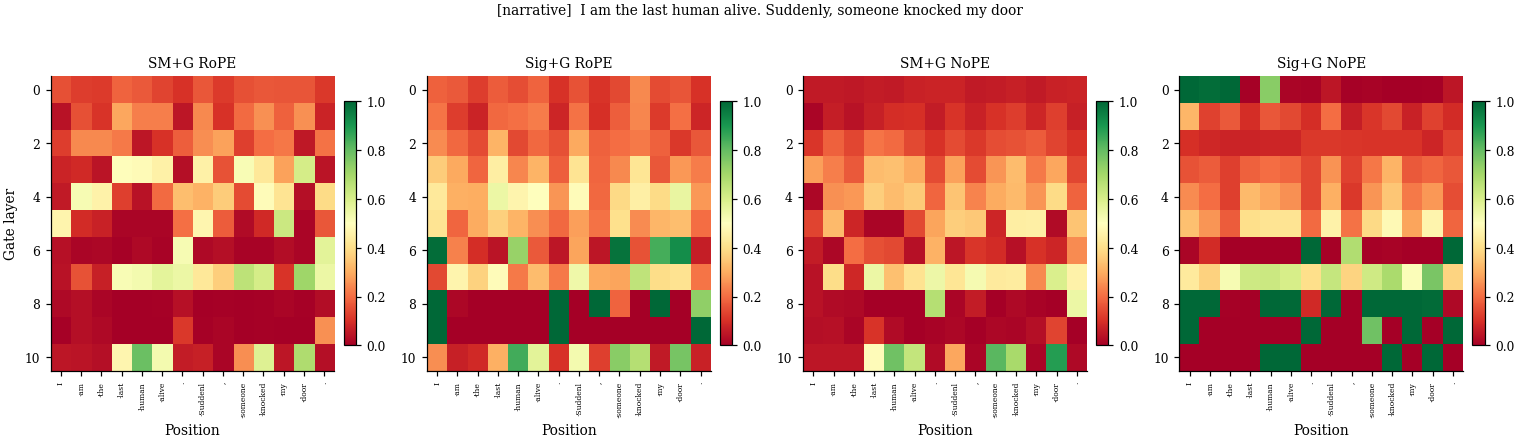

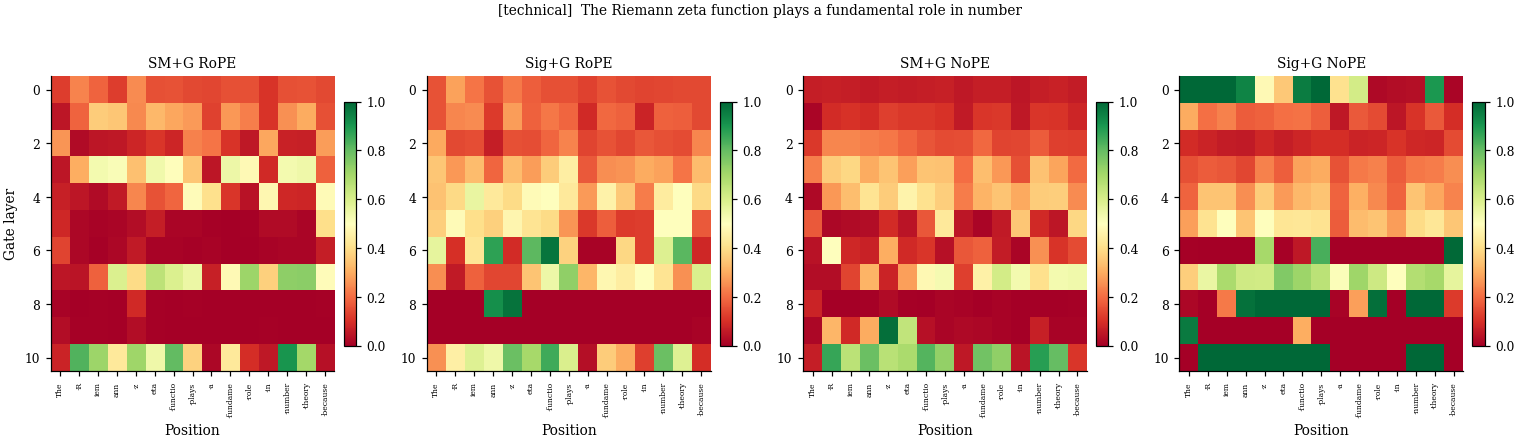

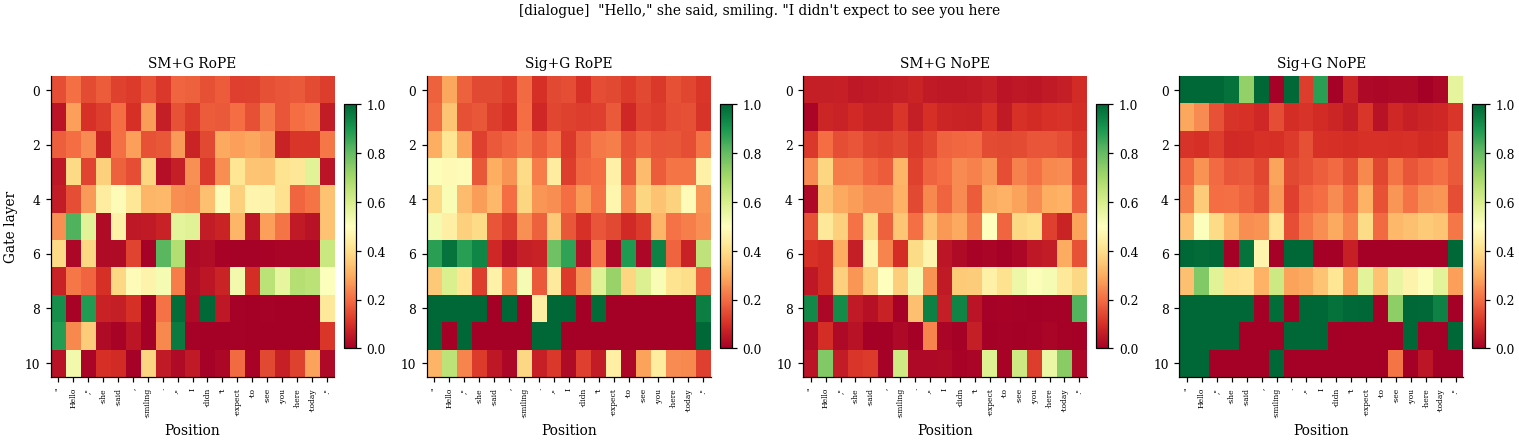

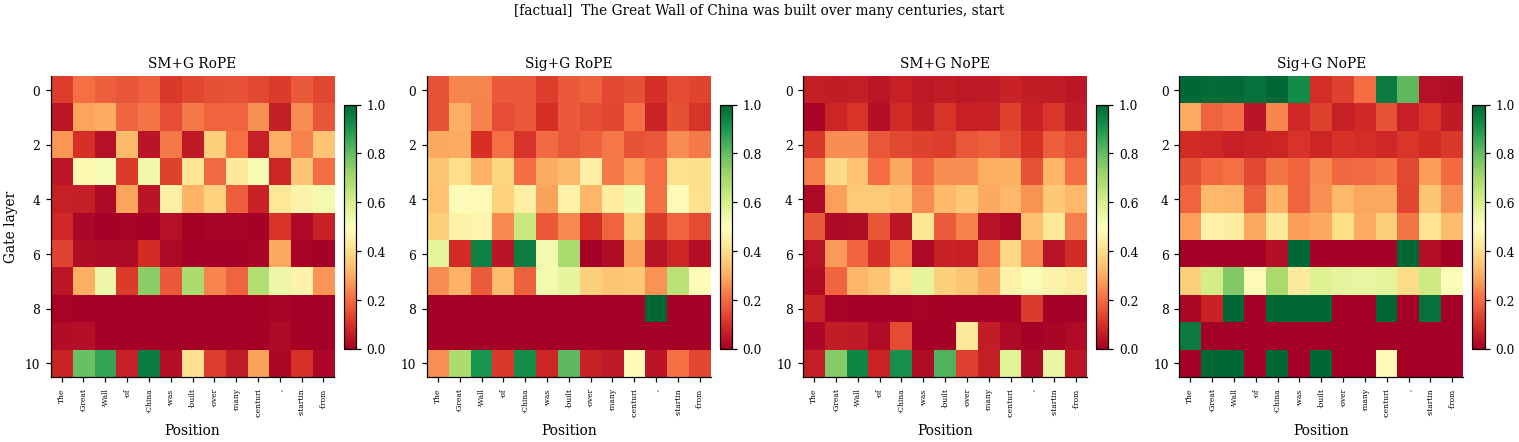

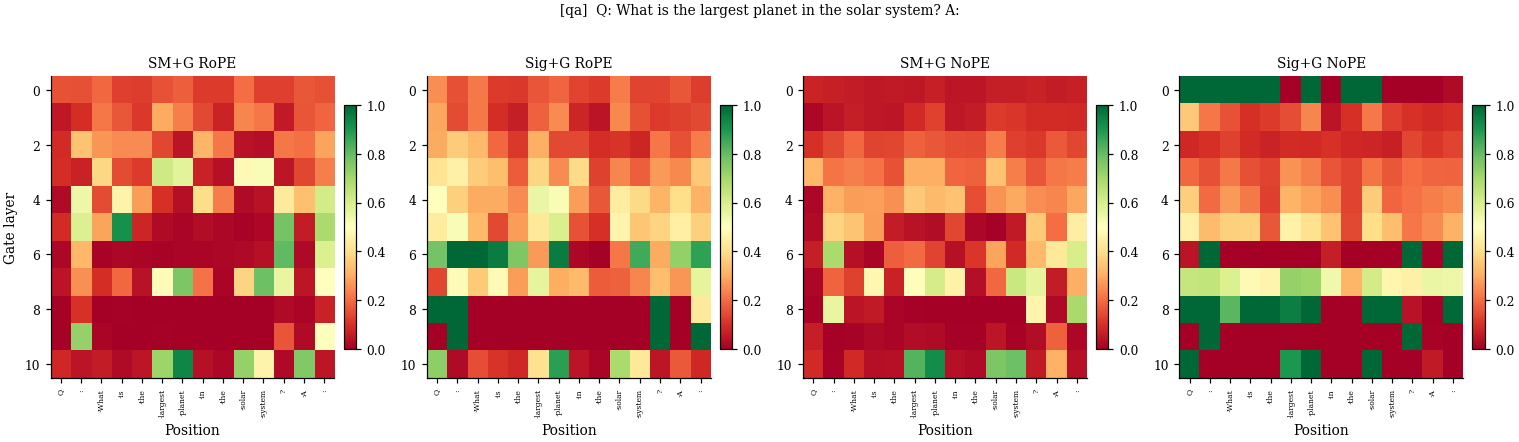

In [14]:
PROMPTS = [
    ("narrative", "I am the last human alive. Suddenly, someone knocked my door."),
    ("technical", "The Riemann zeta function plays a fundamental role in number theory because"),
    ("dialogue",  "\"Hello,\" she said, smiling. \"I didn\'t expect to see you here today.\""),
    ("factual",   "The Great Wall of China was built over many centuries, starting from"),
    ("qa",        "Q: What is the largest planet in the solar system? A:"),
]

# For each prompt, plot 4 gated models side by side (layer x position heatmap)
for label, prompt in PROMPTS:
    fig, axes = plt.subplots(1, len(GATED), figsize=(3.5*len(GATED), 4.0))
    for ax, spec in zip(axes if len(GATED)>1 else [axes], GATED):
        name = spec[0]
        model, cfg, _ = load_model(spec)
        toks = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
        _, gates = extract_attn_and_gate(model, cfg, toks)
        gate_mat = torch.stack([g[0] for g in gates], dim=0).cpu().numpy()  # (L-1, T)
        T = gate_mat.shape[1]
        im = ax.imshow(gate_mat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
        ax.set_title(spec[1], fontsize=9)
        ax.set_xlabel("Position")
        if ax is axes[0] if len(GATED)>1 else True: ax.set_ylabel("Gate layer")
        if T <= 24:
            tok_strs = [tokenizer.decode([t]).replace("\n", "\\n").replace(" ", "·")[:8]
                        for t in toks[0].cpu().tolist()]
            ax.set_xticks(range(T))
            ax.set_xticklabels(tok_strs, rotation=90, fontsize=5)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
        del model; torch.cuda.empty_cache()
    plt.suptitle(f"[{label}]  {prompt[:60]}", fontsize=9, y=1.02)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"{FIG_DIR}/sup_gate_heatmap_{label}.{ext}", dpi=300)
    plt.show()


## Persist all token-level stats


In [15]:
def latex_token(tok, max_len=8):
    """Make a tokenizer-decoded string safe for inclusion inside \\verb|...|.
    Drop or escape characters that would break \\verb (which forbids the delimiter and newlines)."""
    s = tok.replace("\\", "\\textbackslash{}")
    s = s.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "")
    # The pipe is our \verb delimiter — replace with the broken-bar lookalike to avoid termination
    s = s.replace("|", "\u00a6")
    # Trim
    return s[:max_len]

# Top-10 by mean SOFT GATE (existing ranking)
lines = ["% Top-10 dropped/reserved by mean learned soft gate value",
         "\\begin{tabular}{l|" + "ll"*len(GATED) + "}",
         "\\toprule",
         "rank & " + " & ".join(f"\\multicolumn{{2}}{{c}}{{{s[1]}}}" for s in GATED) + " \\\\"]
lines.append(" & " + " & ".join(["drop ($\\bar g$) & keep ($\\bar g$)"] * len(GATED)) + " \\\\")
lines.append("\\midrule")
for r in range(10):
    row = f"{r+1}"
    for s in GATED:
        if s[0] not in top10_results:
            row += " & -- & --"; continue
        d = top10_results[s[0]]["drops"][r]
        k = top10_results[s[0]]["keeps"][r]
        d_str = f"\\verb|{latex_token(tokenizer.decode([d[0]]))}| ({d[1]:.2f})"
        k_str = f"\\verb|{latex_token(tokenizer.decode([k[0]]))}| ({k[1]:.2f})"
        row += f" & {d_str} & {k_str}"
    row += " \\\\"
    lines.append(row)
lines += ["\\bottomrule", "\\end{tabular}"]
with open(f"{TBL_DIR}/table_top10_tokens_soft.tex", "w") as f: f.write("\n".join(lines))
print(f"Saved {TBL_DIR}/table_top10_tokens_soft.tex  (soft-gate ranking)")

# Top-10 by ACTUAL DROP RATE under hard τ (operationally relevant)
lines = ["% Top-10 by actual drop rate under hard τ-thresholding",
         "\\begin{tabular}{l|" + "ll"*len(GATED) + "}",
         "\\toprule",
         "rank & " + " & ".join(f"\\multicolumn{{2}}{{c}}{{{s[1]}}}" for s in GATED) + " \\\\"]
lines.append(" & " + " & ".join(["evicted (rate) & retained (rate)"] * len(GATED)) + " \\\\")
lines.append("\\midrule")
for r in range(10):
    row = f"{r+1}"
    for s in GATED:
        if s[0] not in actual_top10:
            row += " & -- & --"; continue
        d = actual_top10[s[0]]["drops"][r]
        k = actual_top10[s[0]]["keeps"][r]
        d_str = f"\\verb|{latex_token(tokenizer.decode([d[0]]))}| ({d[1]*100:.0f}\\%)"
        k_str = f"\\verb|{latex_token(tokenizer.decode([k[0]]))}| ({k[1]*100:.0f}\\%)"
        row += f" & {d_str} & {k_str}"
    row += " \\\\"
    lines.append(row)
lines += ["\\bottomrule", "\\end{tabular}",
          "% Drop rate = $\\Pr(g < \\tau)$ measured over $\\sim$100K test tokens at each model's best $\\tau$."]
with open(f"{TBL_DIR}/table_top10_tokens_actual.tex", "w") as f: f.write("\n".join(lines))
print(f"Saved {TBL_DIR}/table_top10_tokens_actual.tex  (actual eviction ranking)")

# Pickle full stats (numpy-ified)
serial = {}
for name, st in token_stats.items():
    serial[name] = {k: v.numpy() if hasattr(v, "numpy") else v
                    for k, v in st.items() if k != "spec"}
    serial[name]["display"] = next(s[1] for s in MODEL_SPECS if s[0]==name)
serial["_top10_soft"]    = top10_results       # ranked by mean soft gate
serial["_top10_actual"]  = actual_top10        # ranked by P(g < best_tau)
serial["_buckets"] = bucket_results
serial["_config"] = {"n_seqs": N_TEST, "T_per_seq": T_PER_SEQ, "min_count": 100, "split": "test"}
with open(f"{RESULT_DIR}/token_gate_stats.pkl", "wb") as f:
    pickle.dump(serial, f)
print(f"Saved {RESULT_DIR}/token_gate_stats.pkl  "
      f"({os.path.getsize(f'{RESULT_DIR}/token_gate_stats.pkl')/1e6:.1f} MB)")


Saved /content/drive/MyDrive/SigEvict/tables/table_top10_tokens_soft.tex  (soft-gate ranking)
Saved /content/drive/MyDrive/SigEvict/tables/table_top10_tokens_actual.tex  (actual eviction ranking)
Saved /content/drive/MyDrive/SigEvict/results/token_gate_stats.pkl  (53.3 MB)
